# Validação aninhada

**Tema:** Avaliação e Validação de Modelos › Validação Cruzada

Escolher hiperparâmetros pela CV e reportar o melhor escore da própria
busca é otimista. Este notebook mede esse otimismo — primeiro numa
simulação pura da maldição do vencedor, depois numa busca real de
hiperparâmetros em dados de ruído —, implementa a validação aninhada do
zero e com o `scikit-learn`, e discute o custo e o que fazer com o
resultado.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     ParameterGrid)
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.base import clone

rng = np.random.default_rng(632)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. A maldição do vencedor, pura

$M$ configurações com o mesmo desempenho real (0,80) e estimativas de CV
com ruído de desvio 0,02. Comparamos o máximo simulado com a aproximação
$\mu + \sigma\sqrt{2\ln M}$.

In [2]:
mu, sigma = 0.80, 0.02
print(f"{'M':>5s} {'E[max] simulado':>16s} {'aproximação':>12s}")
for M in [2, 5, 10, 50, 100, 1000]:
    sim = rng.normal(mu, sigma, (20000, M)).max(axis=1).mean()
    print(f"{M:>5d} {sim:>16.4f} {mu + sigma * np.sqrt(2 * np.log(M)):>12.4f}")

    M  E[max] simulado  aproximação
    2           0.8114       0.8235
    5           0.8233       0.8359
   10           0.8308       0.8429
   50           0.8450       0.8559
  100           0.8502       0.8607


 1000           0.8648       0.8743


A aproximação assintótica exagera um pouco para $M$ pequeno, mas captura
o essencial: o otimismo cresce com a raiz do logaritmo do número de
tentativas — devagar, mas sem parar.

## 2. Otimismo numa busca real, em dados sem sinal

200 observações de ruído puro (o rótulo não depende de nada). Uma busca
em grade de um SVM com 48 combinações de `C` e `gamma`. A acurácia real
de qualquer modelo aqui é 0,5.

In [3]:
Xr = rng.normal(0, 1, (200, 20))
yr = rng.integers(0, 2, 200)
grade = {"C": np.logspace(-2, 3, 8), "gamma": np.logspace(-4, 1, 6)}
cv_interna = StratifiedKFold(5, shuffle=True, random_state=0)
busca = GridSearchCV(SVC(), grade, cv=cv_interna).fit(Xr, yr)
print(f"melhor escore da busca (NÃO use como estimativa): {busca.best_score_:.3f}")
print(f"melhores hiperparâmetros: {busca.best_params_}")

melhor escore da busca (NÃO use como estimativa): 0.565
melhores hiperparâmetros: {'C': np.float64(0.01), 'gamma': np.float64(0.0001)}


## 3. Validação aninhada do zero

In [4]:
def aninhada_do_zero(estimador, grade, X, y, k_ext=5, k_int=5, semente=1):
    externo = StratifiedKFold(k_ext, shuffle=True, random_state=semente)
    escores, escolhidos = [], []
    for tr, te in externo.split(X, y):
        interno = StratifiedKFold(k_int, shuffle=True, random_state=semente + 1)
        melhor, melhor_cfg = -np.inf, None
        for cfg in ParameterGrid(grade):            # a escolha usa SÓ o treino do fold externo
            s = cross_val_score(clone(estimador).set_params(**cfg), X[tr], y[tr], cv=interno).mean()
            if s > melhor:
                melhor, melhor_cfg = s, cfg
        final = clone(estimador).set_params(**melhor_cfg).fit(X[tr], y[tr])
        escores.append(final.score(X[te], y[te]))   # o fold externo nunca participou da escolha
        escolhidos.append(melhor_cfg)
    return np.array(escores), escolhidos

t0 = time.perf_counter()
escores_ext, cfgs = aninhada_do_zero(SVC(), grade, Xr, yr)
print(f"validação aninhada (do zero): {escores_ext.mean():.3f} ± {escores_ext.std():.3f} "
      f"({time.perf_counter() - t0:.1f}s)")
print("configuração escolhida em cada fold externo:", [(round(c['C'], 2), round(c['gamma'], 4)) for c in cfgs])

validação aninhada (do zero): 0.530 ± 0.066 (5.4s)
configuração escolhida em cada fold externo: [(np.float64(0.01), np.float64(0.0001)), (np.float64(0.01), np.float64(0.0001)), (np.float64(193.07), np.float64(0.0001)), (np.float64(0.01), np.float64(0.0001)), (np.float64(0.01), np.float64(0.0001))]


In [5]:
aninhada_sk = cross_val_score(GridSearchCV(SVC(), grade, cv=cv_interna), Xr, yr,
                              cv=StratifiedKFold(5, shuffle=True, random_state=1))
print(f"validação aninhada (sklearn): {aninhada_sk.mean():.3f}")

validação aninhada (sklearn): 0.545


**Leitura esperada:** o melhor escore da busca fica acima de 0,5 — o
vencedor foi a configuração que o ruído favoreceu. A validação aninhada
volta para perto de 0,5, a verdade. Note também que a configuração
escolhida **muda** de fold para fold: não há uma configuração "certa"
quando não há sinal.

## 4. Repetindo o experimento: o viés é sistemático, não azar

30 bases de ruído diferentes. Para cada uma: melhor escore da busca vs.
validação aninhada (com uma grade menor, para caber no tempo).

      melhor escore da busca  aninhada
mean                   0.558     0.528
std                    0.027     0.035
min                    0.513     0.453
max                    0.620     0.613


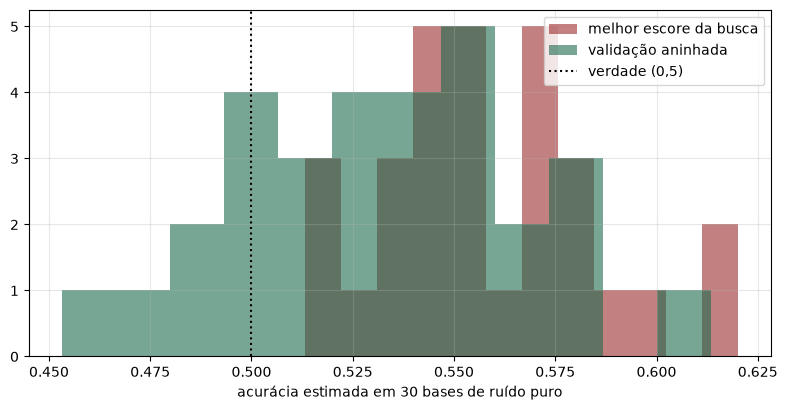

In [6]:
grade_p = {"C": [0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1]}
linhas = []
for s in range(30):
    g = np.random.default_rng(100 + s)
    Xs, ys = g.normal(0, 1, (150, 20)), g.integers(0, 2, 150)
    interno = StratifiedKFold(5, shuffle=True, random_state=s)
    b = GridSearchCV(SVC(), grade_p, cv=interno).fit(Xs, ys)
    an = cross_val_score(GridSearchCV(SVC(), grade_p, cv=interno), Xs, ys,
                         cv=StratifiedKFold(5, shuffle=True, random_state=s + 1)).mean()
    linhas.append({"melhor escore da busca": b.best_score_, "aninhada": an})
res = pd.DataFrame(linhas)
print(res.describe().loc[["mean", "std", "min", "max"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(res["melhor escore da busca"], bins=12, alpha=0.6, color=VERMELHO, label="melhor escore da busca")
ax.hist(res["aninhada"], bins=12, alpha=0.6, color=VERDE, label="validação aninhada")
ax.axvline(0.5, color="black", ls=":", label="verdade (0,5)")
ax.set_xlabel("acurácia estimada em 30 bases de ruído puro"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Com sinal de verdade: quanto custa a honestidade?

Numa base com sinal, a diferença entre o melhor escore e a aninhada é
menor — o vencedor é de fato bom —, mas continua existindo. E o custo em
treinos é multiplicativo.

In [7]:
Xs = rng.normal(0, 1, (800, 10))
ys = (rng.random(800) < 1 / (1 + np.exp(-(Xs[:, 0] * Xs[:, 1] + Xs[:, 2])))).astype(int)
grade_gb = {"learning_rate": [0.03, 0.1, 0.3], "max_leaf_nodes": [7, 15, 31], "l2_regularization": [0, 1.0]}
t0 = time.perf_counter()
b = GridSearchCV(HistGradientBoostingClassifier(max_iter=150, random_state=0), grade_gb,
                 cv=StratifiedKFold(5, shuffle=True, random_state=0)).fit(Xs, ys)
t_busca = time.perf_counter() - t0
t0 = time.perf_counter()
an = cross_val_score(GridSearchCV(HistGradientBoostingClassifier(max_iter=150, random_state=0), grade_gb,
                                  cv=StratifiedKFold(5, shuffle=True, random_state=0)),
                     Xs, ys, cv=StratifiedKFold(5, shuffle=True, random_state=1))
t_an = time.perf_counter() - t0
n_cfg = len(ParameterGrid(grade_gb))
print(f"melhor escore da busca: {b.best_score_:.4f}  ({n_cfg} configs x 5 folds = {n_cfg * 5} treinos, {t_busca:.1f}s)")
print(f"validação aninhada    : {an.mean():.4f}  (5 x {n_cfg * 5} = {5 * n_cfg * 5} treinos, {t_an:.1f}s)")

melhor escore da busca: 0.7050  (18 configs x 5 folds = 90 treinos, 19.9s)
validação aninhada    : 0.6750  (5 x 90 = 450 treinos, 116.2s)


## 6. E o modelo final?

A validação aninhada estima o desempenho do **procedimento** "SVM/boosting
com busca em grade". O modelo que vai para produção é obtido rodando esse
procedimento na base inteira — isto é, o `GridSearchCV` ajustado com
todos os dados (`b.best_estimator_`, que já é re-treinado com tudo por
padrão, `refit=True`). O número que acompanha esse modelo no relatório é
o da aninhada, não o `best_score_`.

In [8]:
print(f"modelo final: {b.best_params_}")
print(f"desempenho a reportar: {an.mean():.3f} (validação aninhada), "
      f"não {b.best_score_:.3f} (melhor escore da busca)")

modelo final: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_leaf_nodes': 7}
desempenho a reportar: 0.675 (validação aninhada), não 0.705 (melhor escore da busca)


## O que levar deste notebook

- O melhor escore de uma busca é otimista por seleção, mesmo sem nenhum
  vazamento de dados.
- Em dados sem sinal, a busca "encontra" desempenho acima do acaso; a
  aninhada, não.
- A aninhada estima o procedimento "modelo + tuning" e custa $K_{ext}$
  vezes a busca.
- Modelo final: o procedimento aplicado à base inteira; número a
  reportar: o da aninhada (ou de um teste tocado uma única vez).

→ Próximo: **Vazamento na validação**.